# Email Spam Detection Using Natural Language Processing

## Team Members

1. Nur Adina binti Zahrulkamar
2. Laila Khadija binti Mohd Nazri
3. Kesshi Akshainie Thevi A/P Saravanan
4. Nurin Afiqah Binti Rosman

## Project Overview

This project develops an Email Spam Detection system using Natural Language Processing (NLP) and Machine Learning techniques. The objective is to classify messages into Spam and Ham (Not Spam) categories. The SMS Spam Collection Dataset containing 5,572 messages was used for model training and evaluation.

## Objectives

1. To preprocess and clean text data using NLP techniques.
2. To implement Bag of Words and TF-IDF feature extraction methods.
3. To compare the performance of Naive Bayes and Support Vector Machine classifiers.
4. To develop an intelligent spam detection application.
5. To evaluate model performance using accuracy, precision, recall, F1-score, and confusion matrix.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
import os

os.listdir('/content/drive/MyDrive/NLP-Spam-Detector/dataset')

['archive (6).zip']

In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/NLP-Spam-Detector/dataset/archive (6).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/NLP-Spam-Detector/dataset/unzipped")

print("Done")

Done


In [5]:
import os

folder = "/content/drive/MyDrive/NLP-Spam-Detector/dataset/unzipped"

print(os.listdir(folder))

['spam.csv']


In [6]:
### load dataset ###

import pandas as pd

file_path = "/content/drive/MyDrive/NLP-Spam-Detector/dataset/unzipped/spam.csv"

df = pd.read_csv(file_path, encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

In [10]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [11]:
### clean the dataset ###

df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
### check for missing values ###

df.isnull().sum()

,0
label,0
message,0


In [14]:
### check spam vs ham counts ###

df['label'].value_counts()

,count
label,
ham,4825
spam,747


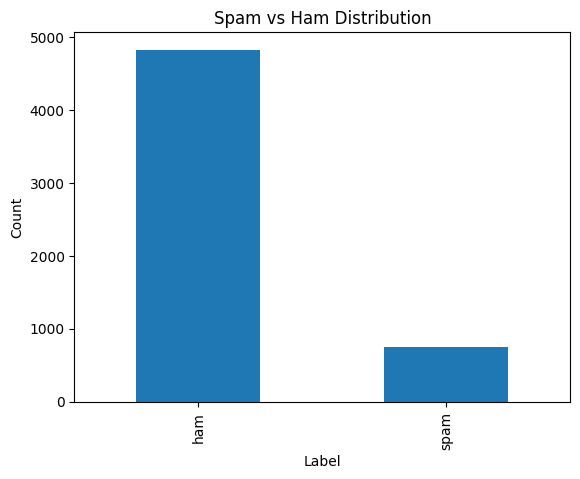

In [16]:
### Visualization 1: Spam vs Ham Distribution ###

import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='bar'
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [19]:
### NLP preprocessing pipeline ###
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [23]:
sample = df['message'][0]

sample

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [24]:
sample = re.sub('[^a-zA-Z]', ' ', sample)

sample = sample.lower()

sample = sample.split()

sample = [
    ps.stem(word)
    for word in sample
    if word not in stopwords.words('english')
]

sample

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat']

In [25]:
corpus = []

for i in range(len(df)):

    review = re.sub(
        '[^a-zA-Z]',
        ' ',
        df['message'][i]
    )

    review = review.lower()

    review = review.split()

    review = [
        ps.stem(word)
        for word in review
        if word not in stopwords.words('english')
    ]

    review = ' '.join(review)

    corpus.append(review)

print("Finished")

Finished


In [26]:
df['processed'] = corpus

df.head()

,label,message,processed
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [27]:
### Feature Extraction #1 (Bag of Words) ###

# Convert Labels to Numbers
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,processed,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,1
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,0


In [28]:
# Create Bag of Words Features

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=3000)

X = cv.fit_transform(
    df['processed']
).toarray()

y = df['label_num']

In [29]:
X.shape

(5572, 3000)

In [30]:
# Split Training and Testing Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4457, 3000)
(1115, 3000)


In [32]:
# Train Your First Model

from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(
    X_train,
    y_train
)

MultinomialNB()

In [33]:
# Make Predictions

predictions = model_nb.predict(
    X_test
)

predictions[:10]

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0])

In [35]:
# check accuracy
from sklearn.metrics import accuracy_score
accuracy_score(
    y_test,
    predictions
)

0.9820627802690582

In [36]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

cm

array([[955,  10],
       [ 10, 140]])

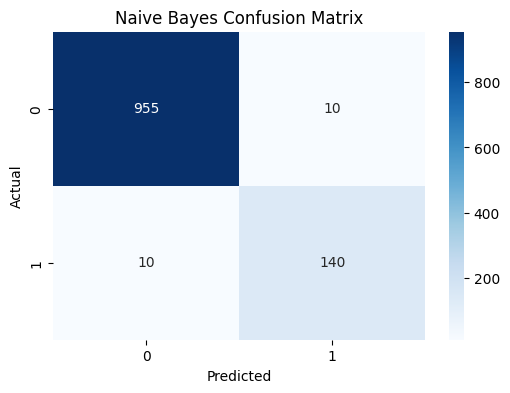

In [37]:
### Visualization 2: Confusion Matrix ###
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [38]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [40]:
### Feature Extraction #2 TF-IDF ###

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Features
tfidf = TfidfVectorizer(
    max_features=3000
)

X_tfidf = tfidf.fit_transform(
    df['processed']
).toarray()

y = df['label_num']

In [41]:
X_tfidf.shape

(5572, 3000)

In [43]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.svm import LinearSVC

# Train SVM
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train_tfidf
)

LinearSVC()

In [45]:
# Make Predictions

svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [46]:
# Check Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test_tfidf,
    svm_predictions
)

0.9820627802690582

In [47]:
### Model Comparison Table ###
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [
        0.9820627802690582,
        0.9820627802690582
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.982063
1,SVM,0.982063


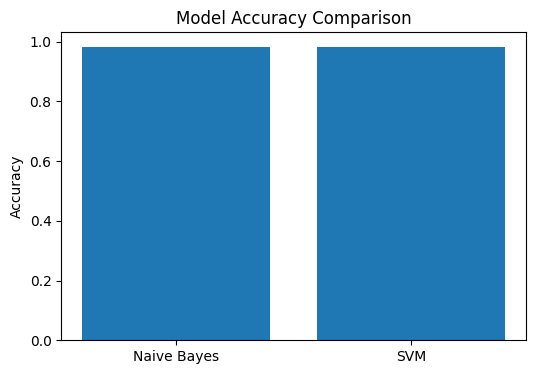

In [48]:
### Visualization 3: Model Comparison ###
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [49]:
!pip install wordcloud
from wordcloud import WordCloud

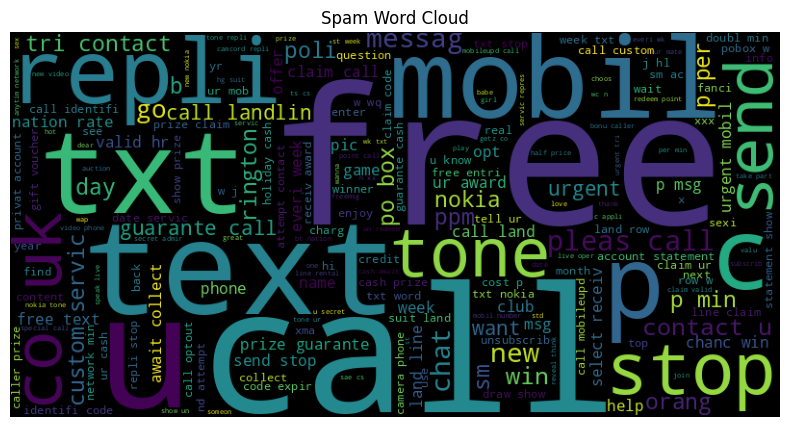

In [51]:
### Visualization 4: Spam Word Cloud ###
spam_words = ' '.join(
    df[df['label'] == 'spam']['processed']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(spam_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Spam Word Cloud")

plt.show()

In [52]:
import pickle

In [53]:
pickle.dump(
    svm_model,
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/spam_model.pkl',
        'wb'
    )
)

In [54]:
pickle.dump(
    tfidf,
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/vectorizer.pkl',
        'wb'
    )
)

In [55]:
# Verify Files Exist
import os

os.listdir(
    '/content/drive/MyDrive/NLP-Spam-Detector/models'
)

['spam_model.pkl', 'vectorizer.pkl']

In [56]:
import pickle

model = pickle.load(
    open(
        "/content/drive/MyDrive/NLP-Spam-Detector/models/spam_model.pkl",
        "rb"
    )
)

print("Model loaded successfully")

Model loaded successfully


In [57]:
vectorizer = pickle.load(
    open(
        "/content/drive/MyDrive/NLP-Spam-Detector/models/vectorizer.pkl",
        "rb"
    )
)

print("Vectorizer loaded successfully")

Vectorizer loaded successfully


In [58]:
### Test a Spam Message ###
message = "WIN FREE CASH NOW"

transformed = vectorizer.transform([message])

prediction = model.predict(transformed)

print(prediction)

[1]


In [59]:
### Test a Normal Message ###
message = "Hey, are we meeting tomorrow?"

transformed = vectorizer.transform([message])

prediction = model.predict(transformed)

print(prediction)

[0]


In [62]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,processed,label_num,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,0,111
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,1,155
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,0,61


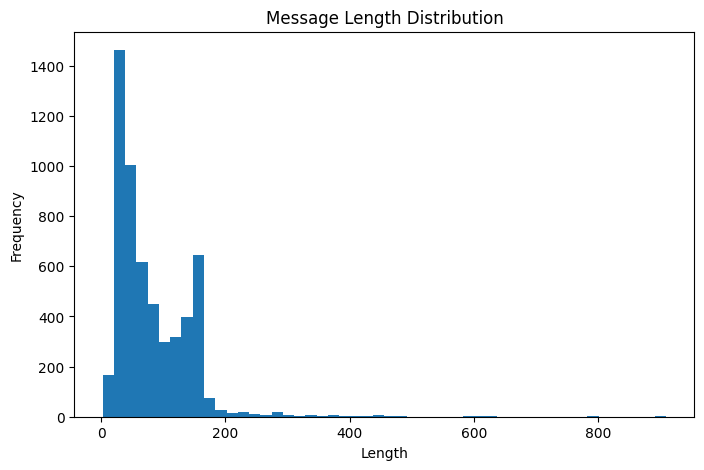

In [64]:
### Visualization 5: Message Length Distribution ###
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df['message_length'],
    bins=50
)

plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()